# Notebook 04 — Modelos Clásicos sobre Embeddings

**Objetivo:** Comparar 5 modelos clásicos de ML entrenados sobre los embeddings de 1024 dimensiones.

**Prerequisito:** `data/embeddings/{train,val,test}_X.npy` deben existir (notebook 03).

Modelos evaluados:
- Logistic Regression (paramétrico)
- K-Nearest Neighbors (no paramétrico)
- Random Forest (ensamble)
- MLP (red neuronal)
- SVM (máquina de soporte vectorial)

Todos usan **exactamente los mismos embeddings** — comparación justa.

In [1]:
# ════════════════════════════════════════════════════════════════
# SETUP — Colab sin auto-push (clone público con destino absoluto)
# ════════════════════════════════════════════════════════════════
import os, sys, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive

    REPO     = "Malaria-Dectetion-Deeplearning"
    REPO_DIR = f"/content/{REPO}"
    REPO_URL = "https://github.com/JuanCOD001116/Malaria-Dectetion-Deeplearning.git"

    os.chdir("/content")

    for stray in (f"/{REPO}", REPO_DIR):
        if os.path.exists(stray) and not os.path.exists(f"{stray}/.git"):
            shutil.rmtree(stray, ignore_errors=True)

    if not os.path.exists(f"{REPO_DIR}/.git"):
        get_ipython().system(f"git clone {REPO_URL} {REPO_DIR}")

    assert os.path.exists(f"{REPO_DIR}/.git"), f"git clone falló: {REPO_DIR}"

    get_ipython().run_line_magic("cd", REPO_DIR)
    get_ipython().system("git pull origin main")
    get_ipython().system("pip install -r requirements.txt -q")

    drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = "/content/drive/MyDrive/malaria_project"
    get_ipython().system(f"mkdir -p {DRIVE_ROOT}/checkpoints {DRIVE_ROOT}/embeddings")
    get_ipython().system("rm -rf artifacts/checkpoints data/embeddings")
    get_ipython().system("mkdir -p artifacts data")
    get_ipython().system(f"ln -sfn {DRIVE_ROOT}/checkpoints artifacts/checkpoints")
    get_ipython().system(f"ln -sfn {DRIVE_ROOT}/embeddings   data/embeddings")
    get_ipython().system("mkdir -p artifacts/figures artifacts/metrics artifacts/logs data/processed")
    print("✓ Colab listo. Pesados → Drive, ligeros → repo local.")

cwd = Path().resolve()
REPO_ROOT = cwd if (cwd / "src").exists() else cwd.parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
print(f"Working dir: {REPO_ROOT}")

Cloning into '/content/Malaria-Dectetion-Deeplearning'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 166 (delta 61), reused 131 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (166/166), 1.52 MiB | 24.77 MiB/s, done.
Resolving deltas: 100% (61/61), done.
/content/Malaria-Dectetion-Deeplearning
From https://github.com/JuanCOD001116/Malaria-Dectetion-Deeplearning
 * branch            main       -> FETCH_HEAD
Already up to date.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2

In [2]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.seed import set_global_seed
from src.utils.io import load_config, load_embeddings, save_json
from src.training.train_classical import train_single_model
from src.evaluation.confusion import plot_confusion_matrix
from src.visualization.training_plots import plot_metrics_comparison

set_global_seed(42)
%matplotlib inline

In [3]:
cfg = load_config('configs/classical.yaml')
X_train, y_train = load_embeddings('train', cfg['embeddings_dir'])
X_val,   y_val   = load_embeddings('val',   cfg['embeddings_dir'])
X_test,  y_test  = load_embeddings('test',  cfg['embeddings_dir'])
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (19290, 1024) | Val: (4133, 1024) | Test: (4135, 1024)


In [4]:
from pathlib import Path
out_dir = Path(cfg['output_dir'])
fig_dir = Path(cfg['figures_dir'])
out_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

all_results = {}
trained_models = {}

for model_name, model_cfg in cfg['models'].items():
    if not model_cfg.get('enabled', True):
        continue
    print(f'\n▶ Entrenando: {model_name}...')
    results, model = train_single_model(
        model_name=model_name, model_cfg=model_cfg,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        X_test=X_test,   y_test=y_test,
        cv_folds=cfg['cv_folds'], seed=cfg['seed'],
        bootstrap_cfg=cfg['bootstrap'],
    )
    all_results[model_name] = results
    trained_models[model_name] = model

    test_acc = results['splits']['test']['accuracy']
    test_f1  = results['splits']['test']['f1_macro']
    test_auc = results['splits']['test'].get('roc_auc', float('nan'))
    print(f'  acc={test_acc:.4f} | f1={test_f1:.4f} | AUC={test_auc:.4f}')
    print(f'  Mejor params: {results["best_params"]}')


▶ Entrenando: logistic_regression...
2026-05-27 02:05:38 [INFO] train_classical: Entrenando: logistic_regression


INFO:train_classical:Entrenando: logistic_regression
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


2026-05-27 02:06:14 [INFO] train_classical:   Mejor params: {'clf__C': 1.0, 'clf__penalty': 'l2'}


INFO:train_classical:  Mejor params: {'clf__C': 1.0, 'clf__penalty': 'l2'}


2026-05-27 02:06:14 [INFO] train_classical:   CV F1-macro: 0.9866 | Tiempo: 35.2s


...

2026-05-27 02:14:00 [INFO] train_classical:   Mejor params: {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}


INFO:train_classical:  Mejor params: {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}


2026-05-27 02:14:00 [INFO] train_classical:   CV F1-macro: 0.9863 | Tiempo: 106.8s


INFO:train_classical:  CV F1-macro: 0.9863 | Tiempo: 106.8s


  acc=0.9703 | f1=0.9703 | AUC=nan
  Mejor params: {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}


In [5]:
# Guardar resultados y modelos
for name, r in all_results.items():
    save_json(r, out_dir / f'{name}.json')

Path('artifacts/checkpoints').mkdir(parents=True, exist_ok=True)
with open('artifacts/checkpoints/classical_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)
print('Modelos y métricas guardados.')

Modelos y métricas guardados.


In [6]:
# Tabla comparativa
rows = []
for name, r in all_results.items():
    test = r['splits']['test']
    ci   = test.get('bootstrap_ci_95', {})
    rows.append({
        'Modelo': name,
        'Train Acc': round(r['splits']['train']['accuracy'], 4),
        'Val Acc':   round(r['splits']['val']['accuracy'],   4),
        'Test Acc':  round(test['accuracy'], 4),
        'Test F1':   round(test['f1_macro'], 4),
        'Test AUC':  round(test.get('roc_auc', float('nan')), 4),
        'Test BAcc': round(test['balanced_accuracy'], 4),
        'CI lower':  round(ci.get('accuracy', {}).get('lower', float('nan')), 4),
        'CI upper':  round(ci.get('accuracy', {}).get('upper', float('nan')), 4),
    })

df_results = pd.DataFrame(rows).sort_values('Test F1', ascending=False)
print('\n=== TABLA COMPARATIVA ===')
display(df_results)
df_results.to_csv(out_dir / 'comparison_table.csv', index=False)


=== TABLA COMPARATIVA ===


,Modelo,Train Acc,Val Acc,Test Acc,Test F1,Test AUC,Test BAcc,CI lower,CI upper
4,svm,0.9903,0.9780,0.9703,0.9703,NaN,0.9703,0.9644,0.9756
3,mlp,0.9883,0.9763,0.9703,0.9703,0.9932,0.9703,0.9649,0.9758
1,knn,0.9888,0.9756,0.9700,0.9700,0.9852,0.9700,0.9640,0.9753
0,logistic_regression,0.9899,0.9775,0.9698,0.9698,0.9931,0.9698,0.9642,0.9753
2,random_forest,0.9948,0.9862,0.9688,0.9688,0.9928,0.9688,0.9635,0.9741


In [7]:
# Barplot comparativo
summary = {name: {'test_f1_macro': all_results[name]['splits']['test']['f1_macro']} for name in all_results}
fig = plot_metrics_comparison(summary, metric='test_f1_macro',
                               save_path='artifacts/figures/models_comparison.png')
plt.show()

In [8]:
# Matrices de confusión
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    fig = plot_confusion_matrix(y_test, y_pred, model_name=name,
                                 save_path=f'artifacts/figures/cm_{name}.png')
    plt.show()
    plt.close()

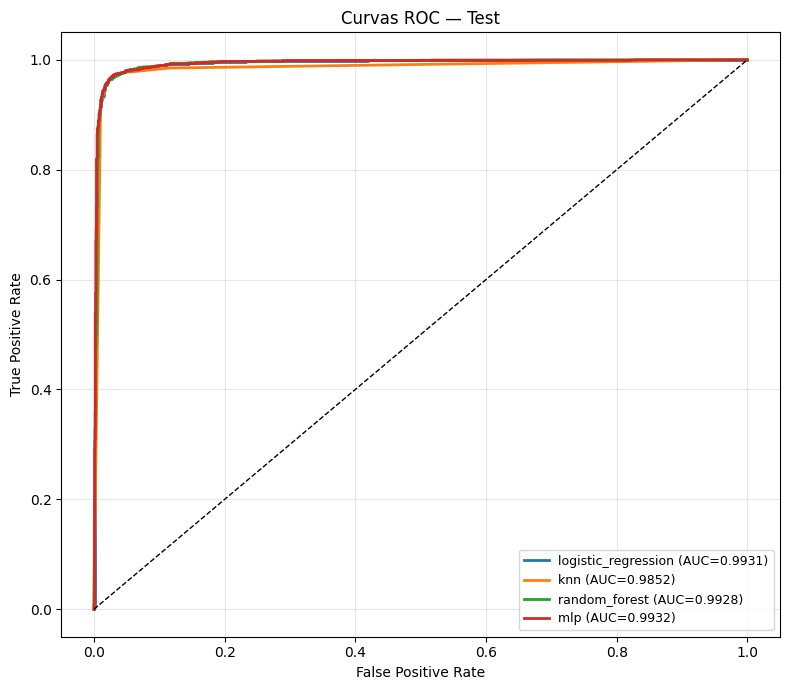

In [9]:
# Curvas ROC
from sklearn.metrics import roc_curve, auc
fig, ax = plt.subplots(figsize=(8, 7))
colors = plt.cm.tab10.colors

for i, (name, model) in enumerate(trained_models.items()):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i % 10], lw=2, label=f'{name} (AUC={roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Test')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ════════════════════════════════════════════════════════════════
# DESCARGA MANUAL — baja el .ipynb ejecutado a tu PC
# Sin auto-push: tú subes/entregas el notebook por el medio que prefieras.
# ════════════════════════════════════════════════════════════════
if IN_COLAB:
    NOTEBOOK = "04_classical_models"
    # Forzar guardado del .ipynb (preserva outputs y figuras embebidas)
    try:
        from google.colab import _message
        _message.blocking_request("save_notebook", request="", timeout_sec=10)
    except Exception:
        pass
    # Descargar a tu PC (revisa carpeta de descargas)
    from google.colab import files
    files.download(f"notebooks/{NOTEBOOK}.ipynb")
    print(f"✓ Descarga iniciada: {NOTEBOOK}.ipynb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descarga iniciada: 04_classical_models.ipynb
